In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arlysonn/cenipa/aeronave.csv
/kaggle/input/datasets/arlysonn/cenipa/ocorrencia.csv
/kaggle/input/datasets/arlysonn/cenipa/ocorrencia_tipo.csv


# IA 2 — Análise de Risco e Classificação da Severidade de Ocorrências Aeronáuticas Brasileiras

Este notebook utiliza dados reais do CENIPA para analisar a severidade de ocorrências aeronáuticas brasileiras.

A severidade será representada pela classificação da ocorrência:

- Incidente: menor severidade
- Incidente Grave: severidade intermediária
- Acidente: maior severidade

Objetivos:

1. Identificar padrões associados a ocorrências mais graves.
2. Analisar taxa de gravidade por tipo de operação, aeronave, fase de voo e tipo de ocorrência.
3. Treinar um modelo Random Forest para classificação e interpretação das variáveis.
4. Treinar uma rede neural MLP como técnica de IA II.
5. Comparar os modelos e discutir os resultados.

In [2]:
import glob
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print('Bibliotecas carregadas.')

2026-05-24 16:27:06.375569: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779640026.653277      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779640026.735843      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779640027.420207      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779640027.420261      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779640027.420265      16 computation_placer.cc:177] computation placer alr

Bibliotecas carregadas.


In [3]:
def achar_arquivo(nome):
    arquivos = glob.glob(f'/kaggle/input/**/{nome}', recursive=True)
    
    if not arquivos:
        raise FileNotFoundError(f'Arquivo não encontrado: {nome}')
    
    return arquivos[0]


def ler_csv(nome):
    caminho = achar_arquivo(nome)
    
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            return pd.read_csv(
                caminho,
                sep=';',
                encoding=enc,
                low_memory=False
            )
        except UnicodeDecodeError:
            pass
    
    return pd.read_csv(
        caminho,
        sep=';',
        encoding='latin-1',
        low_memory=False
    )


def limpar_numero(serie):
    return pd.to_numeric(
        serie.astype(str)
             .str.replace(',', '.', regex=False)
             .str.replace('*', '', regex=False)
             .str.strip(),
        errors='coerce'
    )


def texto_padrao(serie):
    return (
        serie.astype('object')
             .fillna('DESCONHECIDO')
             .astype(str)
             .str.strip()
             .str.upper()
    )


def agrupar_raros(serie, min_count=20):
    s = texto_padrao(serie)
    contagens = s.value_counts()
    raros = contagens[contagens < min_count].index
    
    return s.where(~s.isin(raros), 'OUTROS')


def tabela_risco(df, coluna, min_total=30):
    tab = (
        df.groupby(coluna)
          .agg(
              total=('target', 'count'),
              incidentes=('target', lambda x: (x == 0).sum()),
              incidentes_graves=('target', lambda x: (x == 1).sum()),
              acidentes=('target', lambda x: (x == 2).sum())
          )
          .reset_index()
    )
    
    tab['taxa_incidente'] = tab['incidentes'] / tab['total']
    tab['taxa_incidente_grave'] = tab['incidentes_graves'] / tab['total']
    tab['taxa_acidente'] = tab['acidentes'] / tab['total']
    tab['taxa_gravidade'] = (tab['incidentes_graves'] + tab['acidentes']) / tab['total']
    
    tab = tab[tab['total'] >= min_total].copy()
    tab = tab.sort_values('taxa_gravidade', ascending=False)
    
    return tab


print('Funções prontas.')

Funções prontas.


In [4]:
ocorrencia = ler_csv('ocorrencia.csv')
aeronave = ler_csv('aeronave.csv')
ocorrencia_tipo = ler_csv('ocorrencia_tipo.csv')

print('Ocorrência:', ocorrencia.shape)
print('Aeronave:', aeronave.shape)
print('Ocorrência tipo:', ocorrencia_tipo.shape)

Ocorrência: (14408, 22)
Aeronave: (14590, 20)
Ocorrência tipo: (15201, 3)


In [5]:
print('Colunas ocorrência:')
print(ocorrencia.columns.tolist())

print('\nColunas aeronave:')
print(aeronave.columns.tolist())

print('\nColunas ocorrência tipo:')
print(ocorrencia_tipo.columns.tolist())

Colunas ocorrência:
['codigo_ocorrencia', 'codigo_ocorrencia1', 'codigo_ocorrencia2', 'codigo_ocorrencia3', 'codigo_ocorrencia4', 'ocorrencia_classificacao', 'ocorrencia_latitude', 'ocorrencia_longitude', 'ocorrencia_cidade', 'ocorrencia_uf', 'ocorrencia_pais', 'ocorrencia_aerodromo', 'ocorrencia_dia', 'ocorrencia_hora', 'investigacao_aeronave_liberada', 'investigacao_status', 'divulgacao_relatorio_numero', 'divulgacao_relatorio_publicado', 'divulgacao_dia_publicacao', 'total_recomendacoes', 'total_aeronaves_envolvidas', 'ocorrencia_saida_pista']

Colunas aeronave:
['codigo_ocorrencia2', 'aeronave_matricula', 'aeronave_tipo_equipamento', 'aeronave_fabricante', 'aeronave_modelo', 'aeronave_tipo_icao', 'aeronave_motor_tipo', 'anv_motor_qtd', 'anv_motor_descricao_qtd', 'aeronave_pmd', 'aeronave_assentos', 'aeronave_ano_fabricacao', 'aeronave_pais_fabricante', 'aeronave_pais_registro', 'aeronave_voo_origem', 'aeronave_voo_destino', 'aeronave_fase_operacao', 'aeronave_tipo_operacao', 'aeron

In [6]:
ocorrencia['id_ocorrencia'] = ocorrencia['codigo_ocorrencia'].astype(str)
aeronave['id_ocorrencia'] = aeronave['codigo_ocorrencia2'].astype(str)
ocorrencia_tipo['id_ocorrencia'] = ocorrencia_tipo['codigo_ocorrencia1'].astype(str)

cols_tipo = [
    c for c in ocorrencia_tipo.columns
    if c not in ['codigo_ocorrencia1', 'id_ocorrencia']
]

tipo_agg = ocorrencia_tipo.groupby('id_ocorrencia')[cols_tipo].agg(
    lambda s: ' | '.join(sorted(set(s.dropna().astype(str))))
).reset_index()

base = ocorrencia.merge(
    aeronave,
    on='id_ocorrencia',
    how='left',
    suffixes=('', '_aeronave')
)

base = base.merge(
    tipo_agg,
    on='id_ocorrencia',
    how='left'
)

print('Base integrada:', base.shape)
display(base.head())

Base integrada: (14590, 45)


,codigo_ocorrencia,codigo_ocorrencia1,codigo_ocorrencia2,codigo_ocorrencia3,codigo_ocorrencia4,ocorrencia_classificacao,ocorrencia_latitude,ocorrencia_longitude,ocorrencia_cidade,ocorrencia_uf,...,aeronave_pais_fabricante,aeronave_pais_registro,aeronave_voo_origem,aeronave_voo_destino,aeronave_fase_operacao,aeronave_tipo_operacao,aeronave_nivel_dano,aeronave_fatalidades_total,ocorrencia_tipo,taxonomia_tipo_icao
0,88522,88522,88522,88522,88522,INCIDENTE,-27.67027777777,-48.5525,FLORIANÓPOLIS,SC,...,BRASIL,BRASIL,FORA DE AERODROMO,HERCÍLIO LUZ,ESTACIONAMENTO,POLICIAL,LEVE,0.0,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,SCF-NP
1,88520,88520,88520,88520,88520,INCIDENTE,-5.060555555555,-42.82444444444,TERESINA,PI,...,BRASIL,BRASIL,SENADOR PETRÔNIO PORTELLA,GOVERNADOR ANDRÉ FRANCO MONTORO,DECOLAGEM,REGULAR,LEVE,0.0,COLISÃO COM AVE,BIRD
2,88519,88519,88519,88519,88519,INCIDENTE,-5.768888888888,-35.36638888888,SÃO GONÇALO DO AMARANTE,RN,...,BRASIL,BRASIL,CONGONHAS,GOVERNADOR ALUÍZIO ALVES,CRUZEIRO,REGULAR,NENHUM,0.0,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,SCF-NP
3,88518,88518,88518,88518,88518,ACIDENTE,-23.86666666666,-52.67027777777,CIANORTE,PR,...,BRASIL,BRASIL,AERÓDROMO NÃO CADASTRADO,AERÓDROMO NÃO CADASTRADO,DECOLAGEM,AGRÍCOLA,SUBSTANCIAL,0.0,EXCURSÃO DE PISTA | PERDA DE CONTROLE NO SOLO,LOC-G | RE
4,88516,88516,88516,88516,88516,ACIDENTE,-28.75444444444,-53.84083333333,CRUZ ALTA,RS,...,BRASIL,BRASIL,FORA DE AERODROMO,AERÓDROMO NÃO CADASTRADO,DECOLAGEM,AGRÍCOLA,DESTRUÍDA,1.0,PERDA DE CONTROLE EM VOO,LOC-I


In [7]:
TARGET = 'ocorrencia_classificacao'

base[TARGET] = texto_padrao(base[TARGET])

base = base[
    base[TARGET].isin(['INCIDENTE', 'INCIDENTE GRAVE', 'ACIDENTE'])
].copy()

mapa_target = {
    'INCIDENTE': 0,
    'INCIDENTE GRAVE': 1,
    'ACIDENTE': 2
}

base['target'] = base[TARGET].map(mapa_target)

base['evento_grave'] = base['target'].isin([1, 2]).astype(int)

print('Distribuição das classes:')
print(base[TARGET].value_counts())

print('\nDistribuição percentual:')
print((base[TARGET].value_counts(normalize=True) * 100).round(2))

print('\nMapeamento:')
print('0 = Incidente')
print('1 = Incidente Grave')
print('2 = Acidente')

Distribuição das classes:
ocorrencia_classificacao
INCIDENTE          10320
ACIDENTE            2992
INCIDENTE GRAVE     1278
Name: count, dtype: int64

Distribuição percentual:
ocorrencia_classificacao
INCIDENTE          70.73
ACIDENTE           20.51
INCIDENTE GRAVE     8.76
Name: proportion, dtype: float64

Mapeamento:
0 = Incidente
1 = Incidente Grave
2 = Acidente


In [8]:
if 'ocorrencia_dia' in base.columns:
    data = pd.to_datetime(
        base['ocorrencia_dia'],
        errors='coerce',
        dayfirst=True
    )
    
    base['mes'] = data.dt.month
    base['dia_semana'] = data.dt.dayofweek
    base['ano'] = data.dt.year

if 'ocorrencia_hora' in base.columns:
    base['hora'] = pd.to_numeric(
        base['ocorrencia_hora'].astype(str).str.slice(0, 2),
        errors='coerce'
    )

colunas_numericas = [
    'ocorrencia_latitude',
    'ocorrencia_longitude',
    'aeronave_pmd',
    'aeronave_assentos',
    'aeronave_ano_fabricacao',
    'anv_motor_qtd',
    'total_aeronaves_envolvidas'
]

for col in colunas_numericas:
    if col in base.columns:
        base[col] = limpar_numero(base[col])

print('Amostra das variáveis temporais e técnicas:')
display(
    base[
        [
            'mes',
            'dia_semana',
            'ano',
            'hora',
            'aeronave_pmd',
            'aeronave_assentos',
            'aeronave_ano_fabricacao',
            'anv_motor_qtd'
        ]
    ].head()
)

Amostra das variáveis temporais e técnicas:


,mes,dia_semana,ano,hora,aeronave_pmd,aeronave_assentos,aeronave_ano_fabricacao,anv_motor_qtd
0,3,6,2026,20.0,2850.0,8.0,2009.0,1.0
1,3,1,2026,15.0,89000.0,234.0,2023.0,2.0
2,3,5,2026,19.0,52290.0,125.0,0.0,2.0
3,3,6,2026,12.0,4762.0,NaN,2020.0,1.0
4,3,0,2026,17.0,3629.0,NaN,2014.0,1.0


In [9]:
base['idade_aeronave'] = base['ano'] - base['aeronave_ano_fabricacao']

base.loc[
    (base['idade_aeronave'] < 0) | (base['idade_aeronave'] > 100),
    'idade_aeronave'
] = np.nan

base['faixa_pmd'] = pd.cut(
    base['aeronave_pmd'],
    bins=[0, 750, 2250, 5700, 27000, np.inf],
    labels=[
        'MUITO_LEVE',
        'LEVE',
        'MEDIO',
        'PESADO',
        'MUITO_PESADO'
    ]
)

base['faixa_hora'] = pd.cut(
    base['hora'],
    bins=[-1, 5, 11, 17, 23],
    labels=[
        'MADRUGADA',
        'MANHA',
        'TARDE',
        'NOITE'
    ]
)

base['fim_de_semana'] = base['dia_semana'].isin([5, 6]).astype(int)

colunas_texto = [
    'aeronave_tipo_equipamento',
    'aeronave_tipo_operacao',
    'aeronave_fase_operacao',
    'aeronave_motor_tipo',
    'ocorrencia_tipo',
    'taxonomia_tipo_icao',
    'ocorrencia_uf'
]

for col in colunas_texto:
    if col in base.columns:
        base[col] = texto_padrao(base[col])

print('Variáveis derivadas criadas.')

display(
    base[
        [
            'idade_aeronave',
            'faixa_pmd',
            'faixa_hora',
            'fim_de_semana',
            'aeronave_tipo_equipamento',
            'aeronave_tipo_operacao',
            'aeronave_fase_operacao'
        ]
    ].head()
)

Variáveis derivadas criadas.


,idade_aeronave,faixa_pmd,faixa_hora,fim_de_semana,aeronave_tipo_equipamento,aeronave_tipo_operacao,aeronave_fase_operacao
0,17.0,MEDIO,NOITE,1,HELICÓPTERO,POLICIAL,ESTACIONAMENTO
1,3.0,MUITO_PESADO,TARDE,0,AVIÃO,REGULAR,DECOLAGEM
2,NaN,MUITO_PESADO,NOITE,1,AVIÃO,REGULAR,CRUZEIRO
3,6.0,MEDIO,TARDE,1,AVIÃO,AGRÍCOLA,DECOLAGEM
4,12.0,MEDIO,TARDE,0,AVIÃO,AGRÍCOLA,DECOLAGEM


In [10]:
categorias_analise = [
    'aeronave_tipo_equipamento',
    'aeronave_tipo_operacao',
    'aeronave_fase_operacao',
    'aeronave_motor_tipo',
    'faixa_pmd',
    'faixa_hora',
    'fim_de_semana',
    'ocorrencia_uf',
    'ocorrencia_tipo',
    'taxonomia_tipo_icao'
]

tabelas_risco = {}

for col in categorias_analise:
    if col in base.columns:
        print('\n' + '=' * 80)
        print(f'Severidade por: {col}')
        print('=' * 80)
        
        tab = tabela_risco(base, col, min_total=30)
        tabelas_risco[col] = tab
        
        display(tab.head(15))


Severidade por: aeronave_tipo_equipamento


,aeronave_tipo_equipamento,total,incidentes,incidentes_graves,acidentes,taxa_incidente,taxa_incidente_grave,taxa_acidente,taxa_gravidade
13,ULTRALEVE,457,73,74,310,0.159737,0.161926,0.678337,0.840263
11,PLANADOR,32,8,3,21,0.250000,0.093750,0.656250,0.750000
1,ANFÍBIO,34,21,2,11,0.617647,0.058824,0.323529,0.382353
9,HELICÓPTERO,1355,890,101,364,0.656827,0.074539,0.268635,0.343173
0,***,79,54,3,22,0.683544,0.037975,0.278481,0.316456
2,AVIÃO,12604,9269,1094,2241,0.735401,0.086798,0.177801,0.264599



Severidade por: aeronave_tipo_operacao


,aeronave_tipo_operacao,total,incidentes,incidentes_graves,acidentes,taxa_incidente,taxa_incidente_grave,taxa_acidente,taxa_gravidade
2,AGRÍCOLA,893,89,117,687,0.099664,0.131019,0.769317,0.900336
5,EXPERIMENTAL,391,80,74,237,0.204604,0.189258,0.606138,0.795396
10,PRIVADA,3488,1702,514,1272,0.487959,0.147362,0.364679,0.512041
6,INSTRUÇÃO,1235,671,225,339,0.543320,0.182186,0.274494,0.456680
4,ESPECIALIZADA,170,95,20,55,0.558824,0.117647,0.323529,0.441176
9,POLICIAL,300,204,36,60,0.680000,0.120000,0.200000,0.320000
12,TÁXI AÉREO,1470,1104,147,219,0.751020,0.100000,0.148980,0.248980
8,NÃO REGULAR,123,94,12,17,0.764228,0.097561,0.138211,0.235772
0,***,1010,920,33,57,0.910891,0.032673,0.056436,0.089109
11,REGULAR,5488,5358,100,30,0.976312,0.018222,0.005466,0.023688



Severidade por: aeronave_fase_operacao


...

,ocorrencia_uf,total,incidentes,incidentes_graves,acidentes,taxa_incidente,taxa_incidente_grave,taxa_acidente,taxa_gravidade
13,MT,663,250,93,320,0.377074,0.140271,0.482655,0.622926
12,MS,354,160,50,144,0.451977,0.141243,0.406780,0.548023
27,TO,124,63,18,43,0.508065,0.145161,0.346774,0.491935
9,GO,675,349,128,198,0.517037,0.189630,0.293333,0.482963
10,MA,185,97,22,66,0.524324,0.118919,0.356757,0.475676
22,RR,167,92,17,58,0.550898,0.101796,0.347305,0.449102
14,PA,616,342,66,208,0.555195,0.107143,0.337662,0.444805
23,RS,773,433,84,256,0.560155,0.108668,0.331177,0.439845
21,RO,91,53,11,27,0.582418,0.120879,0.296703,0.417582
1,AC,113,74,15,24,0.654867,0.132743,0.212389,0.345133



Severidade por: ocorrencia_tipo


,ocorrencia_tipo,total,incidentes,incidentes_graves,acidentes,taxa_incidente,taxa_incidente_grave,taxa_acidente,taxa_gravidade
202,OPERAÇÃO A BAIXA ALTITUDE | PERDA DE CONTROLE ...,42,0,1,41,0.000000,0.023810,0.976190,1.000000
246,VOO CONTROLADO CONTRA O TERRENO,67,1,2,64,0.014925,0.029851,0.955224,0.985075
218,PERDA DE CONTROLE EM VOO,521,12,22,487,0.023033,0.042226,0.934741,0.976967
71,COM TREM DE POUSO | EXCURSÃO DE PISTA,58,3,36,19,0.051724,0.620690,0.327586,0.948276
212,PANE SECA,131,9,24,98,0.068702,0.183206,0.748092,0.931298
134,EXCURSÃO DE PISTA | PERDA DE CONTROLE NO SOLO,234,21,95,118,0.089744,0.405983,0.504274,0.910256
201,OPERAÇÃO A BAIXA ALTITUDE,148,18,25,105,0.121622,0.168919,0.709459,0.878378
232,POUSO LONGO,78,10,24,44,0.128205,0.307692,0.564103,0.871795
192,INDETERMINADO,232,41,12,179,0.176724,0.051724,0.771552,0.823276
115,EXCURSÃO DE PISTA,183,34,69,80,0.185792,0.377049,0.437158,0.814208



Severidade por: taxonomia_tipo_icao


,taxonomia_tipo_icao,total,incidentes,incidentes_graves,acidentes,taxa_incidente,taxa_incidente_grave,taxa_acidente,taxa_gravidade
25,ARC | RE,36,0,18,18,0.000000,0.500000,0.500000,1.000000
79,LALT | LOC-I,42,0,1,41,0.000000,0.023810,0.976190,1.000000
42,CFIT,67,1,2,64,0.014925,0.029851,0.955224,0.985075
95,LOC-I,521,12,22,487,0.023033,0.042226,0.934741,0.976967
86,LOC-G | RE,239,21,95,123,0.087866,0.397490,0.514644,0.912134
78,LALT,148,18,25,105,0.121622,0.168919,0.709459,0.878378
64,FUEL,164,21,33,110,0.128049,0.201220,0.670732,0.871951
120,RE | SCF-NP,116,16,57,43,0.137931,0.491379,0.370690,0.862069
118,RE,261,44,93,124,0.168582,0.356322,0.475096,0.831418
141,UNK,232,41,12,179,0.176724,0.051724,0.771552,0.823276


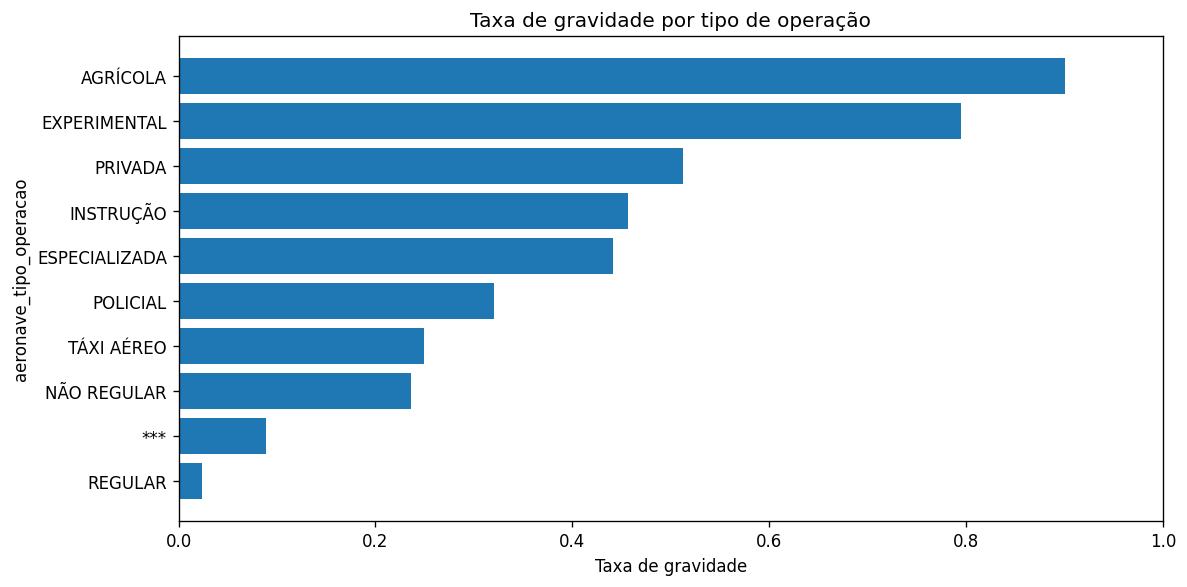

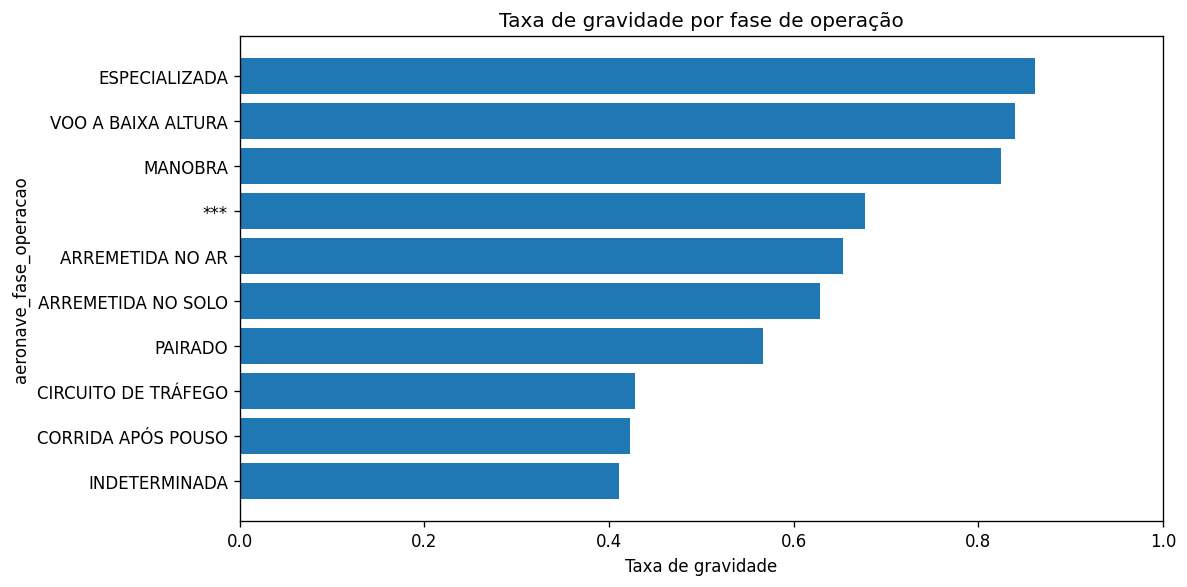

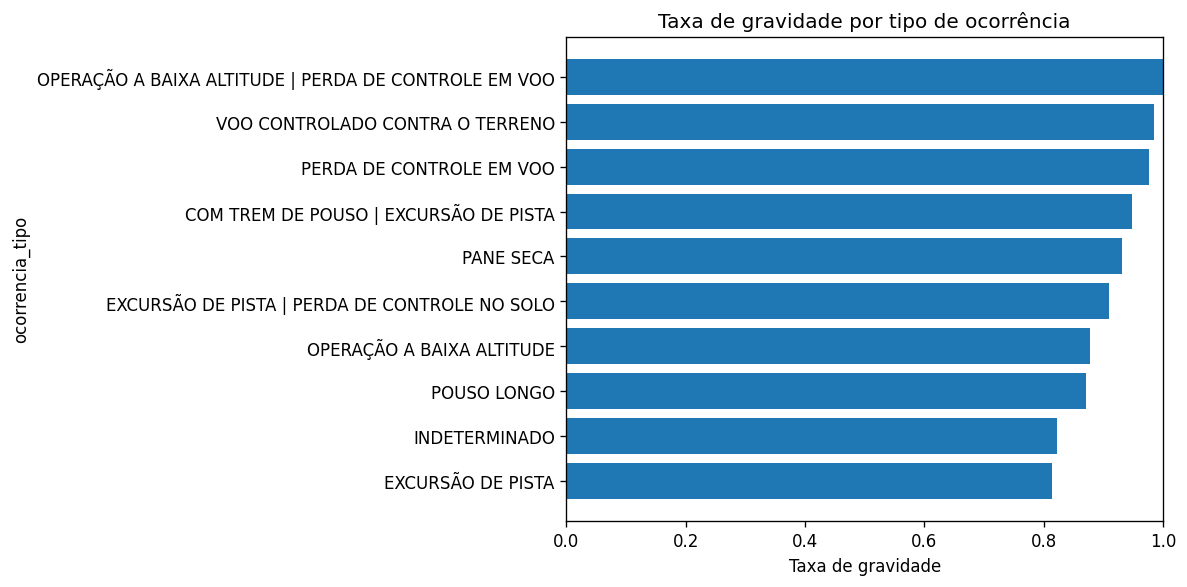

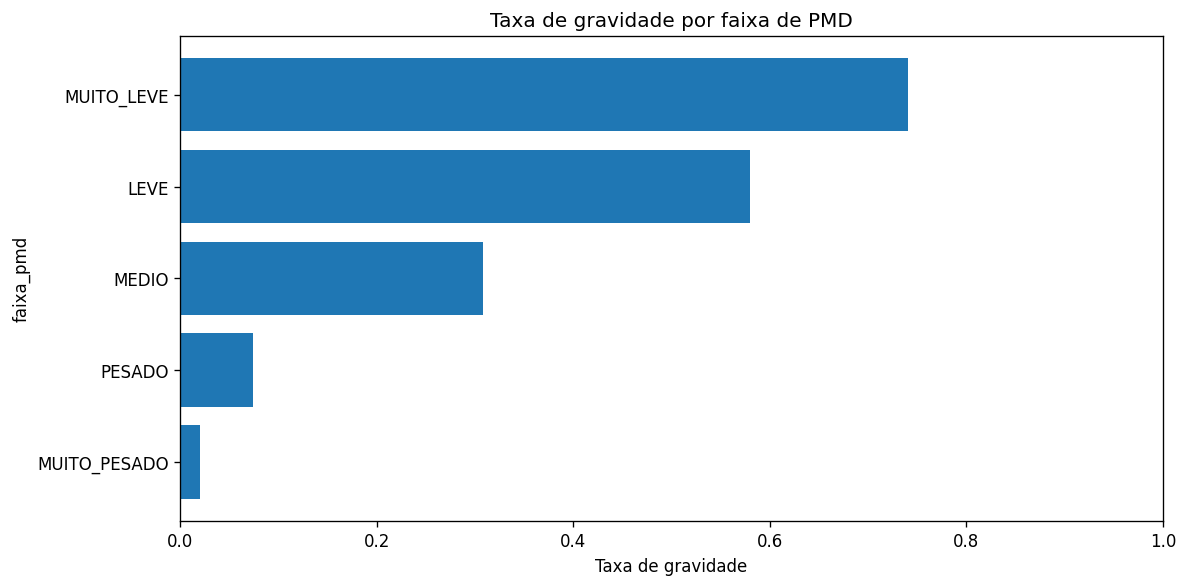

In [11]:
def grafico_taxa_gravidade(tab, coluna, titulo, arquivo, top_n=10):
    dados = tab.head(top_n).sort_values('taxa_gravidade')
    
    plt.figure(figsize=(10, 5))
    plt.barh(
        dados[coluna].astype(str),
        dados['taxa_gravidade']
    )
    
    plt.title(titulo)
    plt.xlabel('Taxa de gravidade')
    plt.ylabel(coluna)
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.savefig(arquivo, dpi=200, bbox_inches='tight')
    plt.show()


grafico_taxa_gravidade(
    tabelas_risco['aeronave_tipo_operacao'],
    'aeronave_tipo_operacao',
    'Taxa de gravidade por tipo de operação',
    'gravidade_tipo_operacao.png',
    top_n=10
)

grafico_taxa_gravidade(
    tabelas_risco['aeronave_fase_operacao'],
    'aeronave_fase_operacao',
    'Taxa de gravidade por fase de operação',
    'gravidade_fase_operacao.png',
    top_n=10
)

grafico_taxa_gravidade(
    tabelas_risco['ocorrencia_tipo'],
    'ocorrencia_tipo',
    'Taxa de gravidade por tipo de ocorrência',
    'gravidade_tipo_ocorrencia.png',
    top_n=10
)

grafico_taxa_gravidade(
    tabelas_risco['faixa_pmd'],
    'faixa_pmd',
    'Taxa de gravidade por faixa de PMD',
    'gravidade_faixa_pmd.png',
    top_n=10
)

In [12]:
colunas_remover_modelo = [
    'codigo_ocorrencia',
    'codigo_ocorrencia1',
    'codigo_ocorrencia2',
    'codigo_ocorrencia3',
    'codigo_ocorrencia4',
    'codigo_ocorrencia2_aeronave',
    'id_ocorrencia',
    'aeronave_matricula',
    
    'aeronave_nivel_dano',
    'aeronave_fatalidades_total',
    'total_recomendacoes',
    'investigacao_aeronave_liberada',
    'investigacao_status',
    'divulgacao_relatorio_numero',
    'divulgacao_relatorio_publicado',
    'divulgacao_dia_publicacao',
    'ocorrencia_saida_pista',
    
    'ocorrencia_pais',
    'ocorrencia_dia',
    'ocorrencia_hora',
    'evento_grave',
    
    TARGET
]

base_modelo = base.drop(
    columns=[c for c in colunas_remover_modelo if c in base.columns],
    errors='ignore'
)

print('Base para modelagem:', base_modelo.shape)
print(base_modelo.columns.tolist())

Base para modelagem: (14590, 33)
['ocorrencia_latitude', 'ocorrencia_longitude', 'ocorrencia_cidade', 'ocorrencia_uf', 'ocorrencia_aerodromo', 'total_aeronaves_envolvidas', 'aeronave_tipo_equipamento', 'aeronave_fabricante', 'aeronave_modelo', 'aeronave_tipo_icao', 'aeronave_motor_tipo', 'anv_motor_qtd', 'anv_motor_descricao_qtd', 'aeronave_pmd', 'aeronave_assentos', 'aeronave_ano_fabricacao', 'aeronave_pais_fabricante', 'aeronave_pais_registro', 'aeronave_voo_origem', 'aeronave_voo_destino', 'aeronave_fase_operacao', 'aeronave_tipo_operacao', 'ocorrencia_tipo', 'taxonomia_tipo_icao', 'target', 'mes', 'dia_semana', 'ano', 'hora', 'idade_aeronave', 'faixa_pmd', 'faixa_hora', 'fim_de_semana']


In [13]:
X = base_modelo.drop(columns='target')
y = base_modelo['target'].astype(int)

X = X.loc[:, X.isna().mean() < 0.70]

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = agrupar_raros(X[col], min_count=20)

X = pd.get_dummies(
    X,
    columns=cat_cols,
    dtype=float
)

X = X.fillna(0)

print('Registros finais:', X.shape[0])
print('Variáveis finais:', X.shape[1])

print('\nDistribuição do alvo:')
print(y.value_counts().sort_index())

print('\nColunas com código remanescentes:')
print([c for c in X.columns if 'codigo' in c.lower()])

print('\nPrimeiras 30 variáveis:')
print(X.columns[:30].tolist())

Registros finais: 14590
Variáveis finais: 826

Distribuição do alvo:
target
0    10320
1     1278
2     2992
Name: count, dtype: int64

Colunas com código remanescentes:
[]

Primeiras 30 variáveis:
['ocorrencia_latitude', 'ocorrencia_longitude', 'total_aeronaves_envolvidas', 'anv_motor_qtd', 'aeronave_pmd', 'aeronave_assentos', 'aeronave_ano_fabricacao', 'mes', 'dia_semana', 'ano', 'hora', 'idade_aeronave', 'fim_de_semana', 'ocorrencia_cidade_ALTAMIRA', 'ocorrencia_cidade_ALTO ALEGRE', 'ocorrencia_cidade_AMERICANA', 'ocorrencia_cidade_ANGRA DOS REIS', 'ocorrencia_cidade_ANÁPOLIS', 'ocorrencia_cidade_ARACAJU', 'ocorrencia_cidade_ARAÇATUBA', 'ocorrencia_cidade_ATIBAIA', 'ocorrencia_cidade_BAURU', 'ocorrencia_cidade_BAYEUX', 'ocorrencia_cidade_BELO HORIZONTE', 'ocorrencia_cidade_BELÉM', 'ocorrencia_cidade_BOA VISTA', 'ocorrencia_cidade_BRAGANÇA PAULISTA', 'ocorrencia_cidade_BRASÍLIA', 'ocorrencia_cidade_CABO FRIO', 'ocorrencia_cidade_CAMPINAS']


In [14]:
X_treino_val, X_teste, y_treino_val, y_teste = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=SEED,
    stratify=y
)

X_treino, X_val, y_treino, y_val = train_test_split(
    X_treino_val,
    y_treino_val,
    test_size=0.1765,
    random_state=SEED,
    stratify=y_treino_val
)

print('Treino:', X_treino.shape)
print('Validação:', X_val.shape)
print('Teste:', X_teste.shape)

print('\nDistribuição treino:')
print(y_treino.value_counts().sort_index())

print('\nDistribuição validação:')
print(y_val.value_counts().sort_index())

print('\nDistribuição teste:')
print(y_teste.value_counts().sort_index())

Treino: (10212, 826)
Validação: (2189, 826)
Teste: (2189, 826)

Distribuição treino:
target
0    7224
1     894
2    2094
Name: count, dtype: int64

Distribuição validação:
target
0    1548
1     192
2     449
Name: count, dtype: int64

Distribuição teste:
target
0    1548
1     192
2     449
Name: count, dtype: int64


In [15]:
scaler = StandardScaler()

X_treino_sc = scaler.fit_transform(X_treino)
X_val_sc = scaler.transform(X_val)
X_teste_sc = scaler.transform(X_teste)

classes = np.array([0, 1, 2])

pesos = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_treino
)

class_weight = {
    int(c): float(p)
    for c, p in zip(classes, pesos)
}

print('Pesos de classe:')
print(class_weight)

print('\nNormalização concluída.')

Pesos de classe:
{0: 0.47120708748615725, 1: 3.807606263982103, 2: 1.6255969436485196}

Normalização concluída.


In [16]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_treino, y_treino)

pred_rf = rf.predict(X_teste)

print('Random Forest treinado.')

Random Forest treinado.


In [17]:
nomes = ['Incidente', 'Incidente Grave', 'Acidente']

print('Random Forest — Relatório de classificação')
print(
    classification_report(
        y_teste,
        pred_rf,
        target_names=nomes,
        zero_division=0
    )
)

acc_rf = accuracy_score(y_teste, pred_rf)
pre_rf = precision_score(y_teste, pred_rf, average='weighted', zero_division=0)
rec_rf = recall_score(y_teste, pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_teste, pred_rf, average='weighted', zero_division=0)

rec_acidente_rf = recall_score(
    y_teste,
    pred_rf,
    labels=[2],
    average=None,
    zero_division=0
)[0]

print('Métricas gerais:')
print('Acurácia:', round(acc_rf, 4))
print('Precisão:', round(pre_rf, 4))
print('Recall:', round(rec_rf, 4))
print('F1-score:', round(f1_rf, 4))
print('Recall Acidente:', round(rec_acidente_rf, 4))

Random Forest — Relatório de classificação
                 precision    recall  f1-score   support

      Incidente       0.95      0.92      0.93      1548
Incidente Grave       0.45      0.39      0.42       192
       Acidente       0.73      0.85      0.79       449

       accuracy                           0.86      2189
      macro avg       0.71      0.72      0.71      2189
   weighted avg       0.86      0.86      0.86      2189

Métricas gerais:
Acurácia: 0.8588
Precisão: 0.8609
Recall: 0.8588
F1-score: 0.8585
Recall Acidente: 0.853


In [18]:
importancias = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_importancias = importancias.head(30).reset_index()
top_importancias.columns = ['variavel', 'importancia']

display(top_importancias)

,variavel,importancia
0,aeronave_pmd,0.051652
1,ano,0.033829
2,aeronave_assentos,0.030445
3,ocorrencia_cidade_OUTROS,0.028798
4,ocorrencia_longitude,0.027756
5,aeronave_tipo_operacao_REGULAR,0.024429
6,idade_aeronave,0.024048
7,ocorrencia_aerodromo_FAER,0.024014
8,faixa_pmd_MUITO_PESADO,0.023598
9,ocorrencia_latitude,0.023362


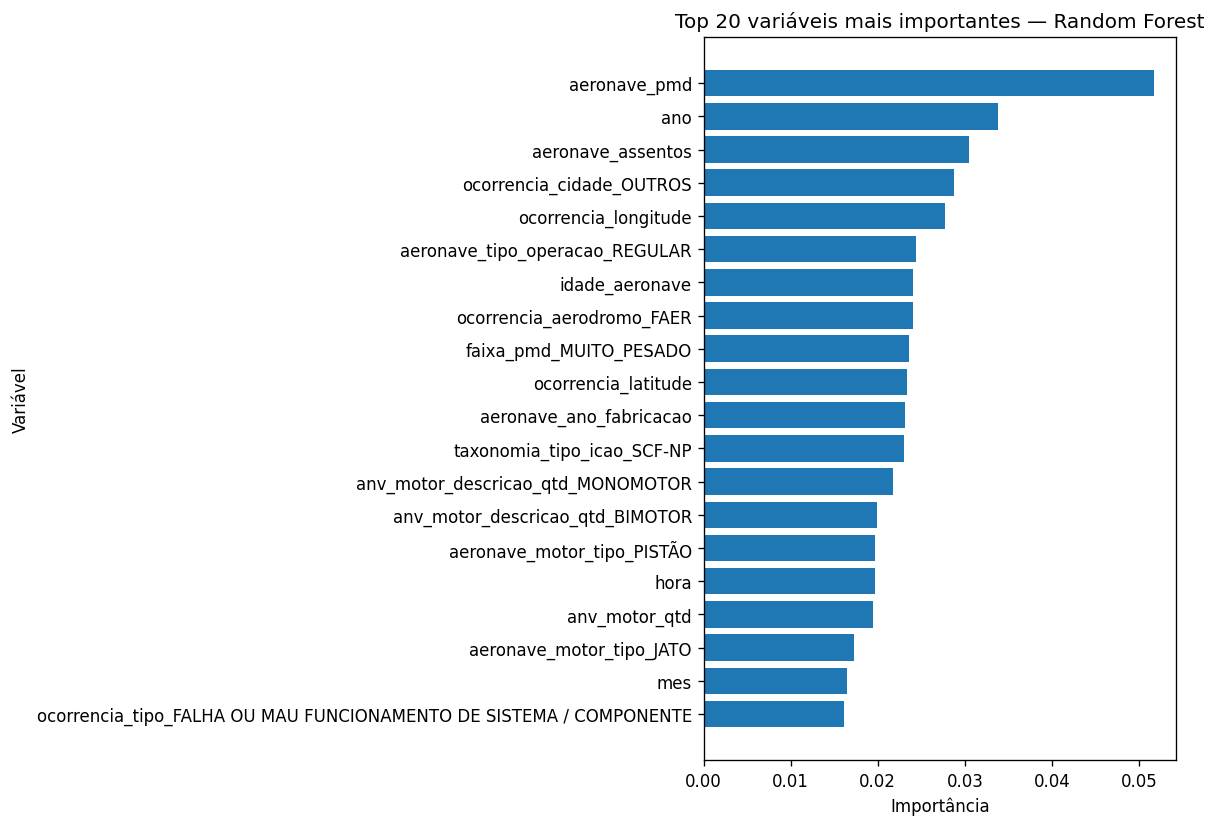

In [19]:
top_20 = importancias.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_20.index[::-1],
    top_20.values[::-1]
)

plt.title('Top 20 variáveis mais importantes — Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')

plt.tight_layout()
plt.savefig('importancia_variaveis_rf.png', dpi=200, bbox_inches='tight')
plt.show()

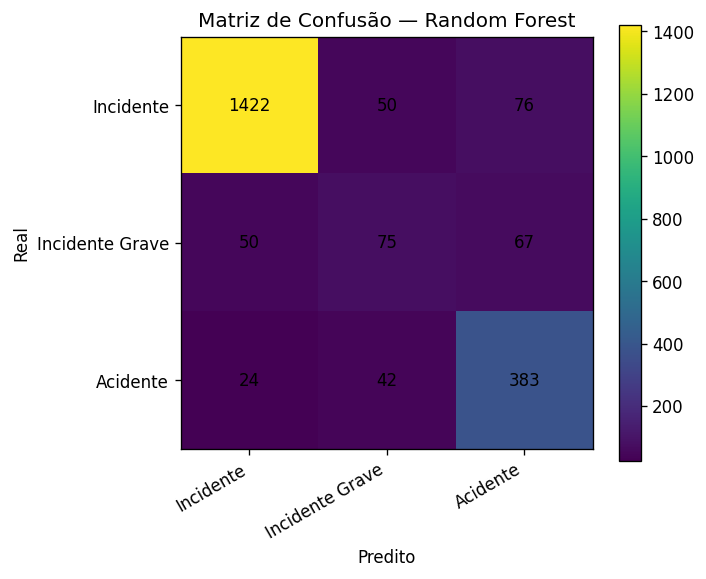

In [20]:
def plot_confusao(y_real, y_pred, titulo, arquivo):
    cm = confusion_matrix(y_real, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm)

    ax.set_title(titulo)
    ax.set_xticks(range(3), nomes, rotation=30, ha='right')
    ax.set_yticks(range(3), nomes)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center'
            )

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(arquivo, dpi=200, bbox_inches='tight')
    plt.show()


plot_confusao(
    y_teste,
    pred_rf,
    'Matriz de Confusão — Random Forest',
    'matriz_confusao_rf.png'
)

In [21]:
def criar_mlp(n_features):
    entrada = keras.Input(shape=(n_features,))

    x = layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(1e-3)
    )(entrada)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.50)(x)

    x = layers.Dense(
        32,
        kernel_regularizer=regularizers.l2(1e-3)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.40)(x)

    x = layers.Dense(
        16,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-3)
    )(x)

    saida = layers.Dense(3, activation='softmax')(x)

    modelo = keras.Model(entrada, saida)

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo


mlp = criar_mlp(X_treino_sc.shape[1])
mlp.summary()

2026-05-24 16:27:58.339496: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 826)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        52,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,971 (218.64 KB)

 Trainable params: 55,779 (217.89 KB)

 Non-trainable params: 192 (768.00 B)

In [22]:
parar = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduzir_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6
)

historico = mlp.fit(
    X_treino_sc,
    y_treino,
    validation_data=(X_val_sc, y_val),
    epochs=300,
    batch_size=128,
    class_weight=class_weight,
    callbacks=[parar, reduzir_lr],
    verbose=1
)

Epoch 1/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1997 - loss: 1.6285 - val_accuracy: 0.3540 - val_loss: 1.3289 - learning_rate: 3.0000e-04
Epoch 2/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2932 - loss: 1.3528 - val_accuracy: 0.5847 - val_loss: 1.1636 - learning_rate: 3.0000e-04
Epoch 3/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4410 - loss: 1.2309 - val_accuracy: 0.6898 - val_loss: 1.0585 - learning_rate: 3.0000e-04
Epoch 4/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5558 - loss: 1.1522 - val_accuracy: 0.7241 - val_loss: 0.9725 - learning_rate: 3.0000e-04
Epoch 5/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6285 - loss: 1.0818 - val_accuracy: 0.7469 - val_loss: 0.8969 - learning_rate: 3.0000e-04
Epoch 6/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6696 - loss: 1.0427 - val_accuracy: 0.7606 - val_loss: 0.8391 - learning_rate: 3.0000e-04
Epoch 7/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7024

In [23]:
proba_mlp = mlp.predict(X_teste_sc)
pred_mlp = np.argmax(proba_mlp, axis=1)

print('MLP Keras — Relatório de classificação')
print(
    classification_report(
        y_teste,
        pred_mlp,
        target_names=nomes,
        zero_division=0
    )
)

acc_mlp = accuracy_score(y_teste, pred_mlp)
pre_mlp = precision_score(y_teste, pred_mlp, average='weighted', zero_division=0)
rec_mlp = recall_score(y_teste, pred_mlp, average='weighted', zero_division=0)
f1_mlp = f1_score(y_teste, pred_mlp, average='weighted', zero_division=0)

rec_acidente_mlp = recall_score(
    y_teste,
    pred_mlp,
    labels=[2],
    average=None,
    zero_division=0
)[0]

resultado = pd.DataFrame([
    {
        'Modelo': 'Random Forest',
        'Acurácia': acc_rf,
        'Precisão': pre_rf,
        'Recall': rec_rf,
        'F1-score': f1_rf,
        'Recall Acidente': rec_acidente_rf
    },
    {
        'Modelo': 'MLP Keras',
        'Acurácia': acc_mlp,
        'Precisão': pre_mlp,
        'Recall': rec_mlp,
        'F1-score': f1_mlp,
        'Recall Acidente': rec_acidente_mlp
    }
])

print('\nComparativo final:')
display(resultado.round(4))

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MLP Keras — Relatório de classificação
                 precision    recall  f1-score   support

      Incidente       0.96      0.88      0.92      1548
Incidente Grave       0.33      0.54      0.41       192
       Acidente       0.73      0.77      0.75       449

       accuracy                           0.82      2189
      macro avg       0.68      0.73      0.69      2189
   weighted avg       0.86      0.82      0.84      2189


Comparativo final:


,Modelo,Acurácia,Precisão,Recall,F1-score,Recall Acidente
0,Random Forest,0.8588,0.8609,0.8588,0.8585,0.8530
1,MLP Keras,0.8246,0.8602,0.8246,0.8388,0.7661


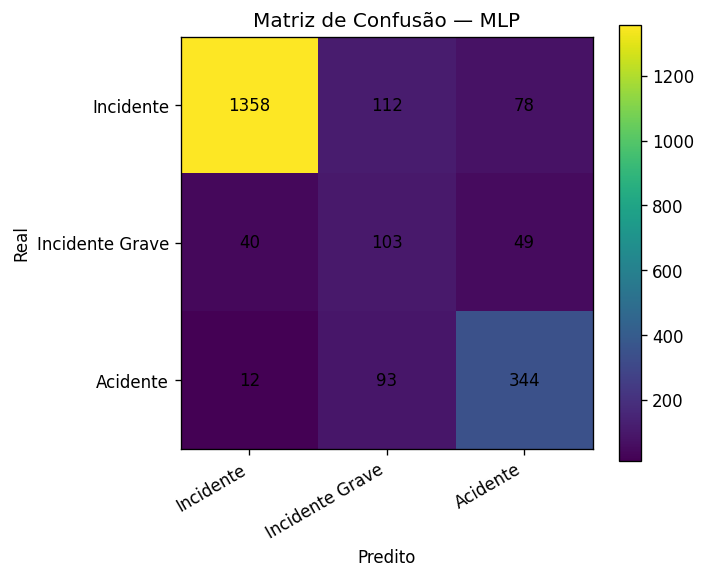

In [24]:
plot_confusao(
    y_teste,
    pred_mlp,
    'Matriz de Confusão — MLP',
    'matriz_confusao_mlp.png'
)

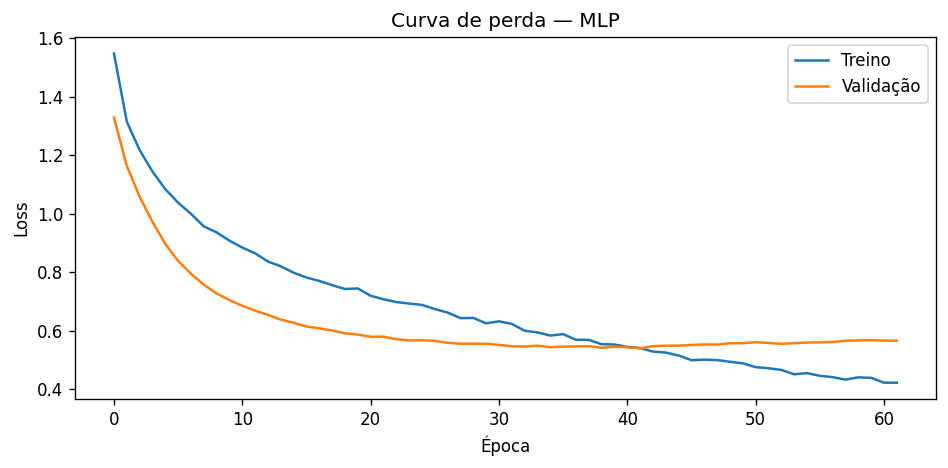

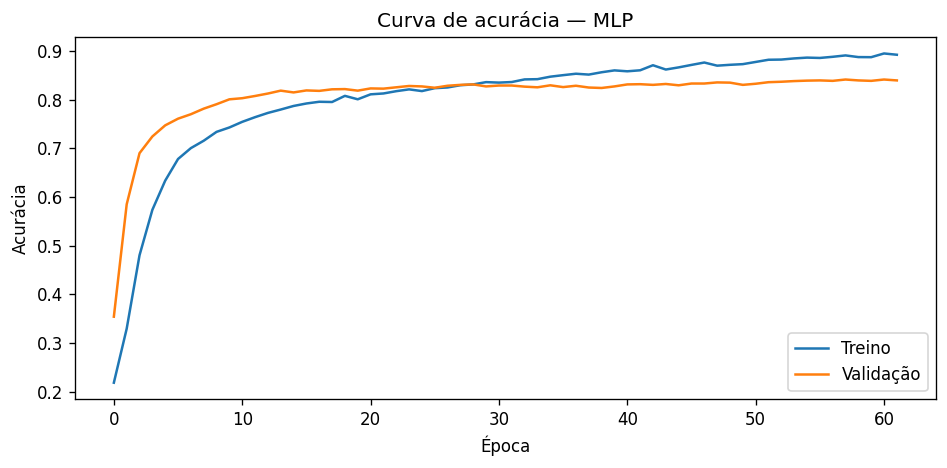

In [25]:
plt.figure(figsize=(8, 4))

plt.plot(historico.history['loss'], label='Treino')
plt.plot(historico.history['val_loss'], label='Validação')

plt.title('Curva de perda — MLP')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('curva_loss_mlp.png', dpi=200, bbox_inches='tight')
plt.show()


plt.figure(figsize=(8, 4))

plt.plot(historico.history['accuracy'], label='Treino')
plt.plot(historico.history['val_accuracy'], label='Validação')

plt.title('Curva de acurácia — MLP')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.savefig('curva_acuracia_mlp.png', dpi=200, bbox_inches='tight')
plt.show()

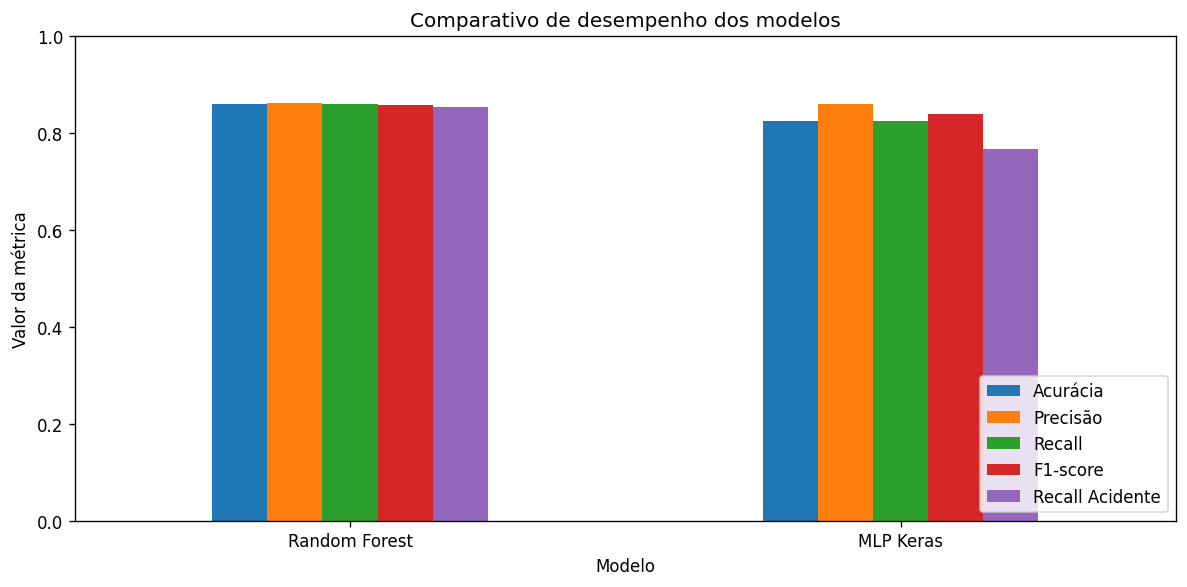

In [26]:
resultado_plot = resultado.set_index('Modelo')[
    ['Acurácia', 'Precisão', 'Recall', 'F1-score', 'Recall Acidente']
]

resultado_plot.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Comparativo de desempenho dos modelos')
plt.ylabel('Valor da métrica')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig('comparativo_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

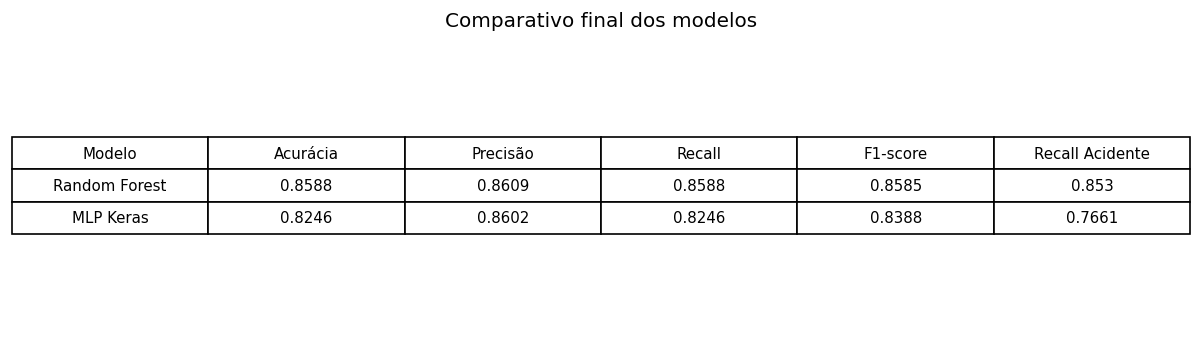

In [27]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

tab = ax.table(
    cellText=resultado.round(4).values,
    colLabels=resultado.columns,
    cellLoc='center',
    loc='center'
)

tab.auto_set_font_size(False)
tab.set_fontsize(9)
tab.scale(1.15, 1.5)

plt.title('Comparativo final dos modelos')
plt.tight_layout()
plt.savefig('tabela_comparativa_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

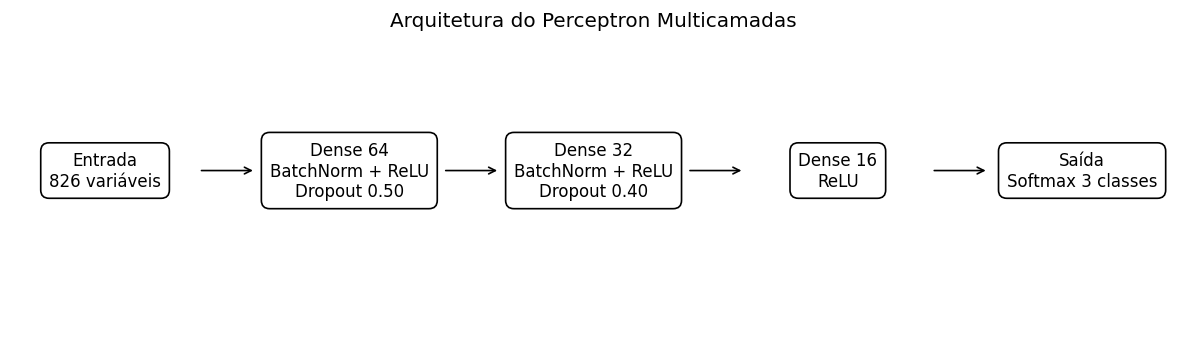

In [28]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

camadas = [
    'Entrada\n826 variáveis',
    'Dense 64\nBatchNorm + ReLU\nDropout 0.50',
    'Dense 32\nBatchNorm + ReLU\nDropout 0.40',
    'Dense 16\nReLU',
    'Saída\nSoftmax 3 classes'
]

xs = np.linspace(0.08, 0.92, len(camadas))

for i, (x, texto) in enumerate(zip(xs, camadas)):
    ax.text(
        x,
        0.55,
        texto,
        ha='center',
        va='center',
        bbox=dict(
            boxstyle='round,pad=0.5',
            fc='white',
            ec='black'
        )
    )

    if i < len(camadas) - 1:
        ax.annotate(
            '',
            xy=(xs[i + 1] - 0.08, 0.55),
            xytext=(x + 0.08, 0.55),
            arrowprops=dict(arrowstyle='->')
        )

plt.title('Arquitetura do Perceptron Multicamadas')
plt.tight_layout()
plt.savefig('arquitetura_mlp.png', dpi=200, bbox_inches='tight')
plt.show()

In [29]:
resultado.to_csv('resultado_modelos.csv', index=False)

top_importancias.to_csv('importancia_variaveis_rf.csv', index=False)

mlp.save('modelo_mlp_cenipa.keras')

with open('features_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(
        list(X.columns),
        f,
        ensure_ascii=False,
        indent=2
    )

print('Arquivos gerados:')
print('resultado_modelos.csv')
print('importancia_variaveis_rf.csv')
print('matriz_confusao_rf.png')
print('matriz_confusao_mlp.png')
print('importancia_variaveis_rf.png')
print('comparativo_modelos.png')
print('tabela_comparativa_modelos.png')
print('curva_loss_mlp.png')
print('curva_acuracia_mlp.png')
print('arquitetura_mlp.png')
print('modelo_mlp_cenipa.keras')
print('features_modelo.json')

Arquivos gerados:
resultado_modelos.csv
importancia_variaveis_rf.csv
matriz_confusao_rf.png
matriz_confusao_mlp.png
importancia_variaveis_rf.png
comparativo_modelos.png
tabela_comparativa_modelos.png
curva_loss_mlp.png
curva_acuracia_mlp.png
arquitetura_mlp.png
modelo_mlp_cenipa.keras
features_modelo.json
